In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os

In [2]:
api_token = os.getenv("HUGGINGFACE_API_KEY")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
    huggingfacehub_api_token=api_token,
)

chat_model = ChatHuggingFace(llm=llm)

/home/sangam/agentic_ai/agentic_ai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [44]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Optional
from pydantic import BaseModel, Field
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import PromptTemplate
import operator

In [86]:
class EvaluationState(BaseModel):
    feedback: str = Field(description="Detailed feedback for score.")
    score: int = Field(description="Score between 1 and 10.", ge=0, le=10)

In [46]:
parser = PydanticOutputParser(
    pydantic_object=EvaluationState
)

In [62]:
prompt = PromptTemplate(
    template="""
{format_instructions}

Evaluate the given essay
and provide detailed feedback which helps student improve their essay
 and a score between 1 and 10.

 Return:
 -feedback: detailed feedback for score.
 -score: score between 1 and 10.

{essay}
""",
    input_variables=["essay"],
    partial_variables={
        "format_instructions": parser.get_format_instructions()
    }
)

In [87]:
structured_model = prompt | chat_model | parser

In [64]:
essay = """

The Importance of Curiosity in Human Life

Curiosity is one of the most powerful traits that human beings possess. It is the desire to learn, explore, and understand the world around us. From childhood to adulthood, curiosity drives people to ask questions, seek answers, and discover new possibilities. Without curiosity, many of the advancements in science, technology, and society would never have been achieved.

One of the greatest benefits of curiosity is that it promotes learning. Curious individuals are naturally motivated to acquire knowledge and develop new skills. They do not simply accept information at face value; instead, they investigate, analyze, and think critically. This habit of continuous learning helps people adapt to changing circumstances and become more informed citizens.

Curiosity also plays a vital role in innovation. Throughout history, inventors, scientists, and explorers have made groundbreaking discoveries because they were curious about how things worked. The invention of the telephone, the discovery of electricity, and the exploration of space all began with simple questions. By encouraging curiosity, societies can foster creativity and progress.

In addition, curiosity enriches personal relationships. People who are genuinely interested in others tend to communicate more effectively and build stronger connections. Asking questions and listening to different perspectives can increase understanding, empathy, and respect among individuals from diverse backgrounds.

However, curiosity must be balanced with responsibility. While seeking knowledge is valuable, it is important to respect privacy, ethics, and safety. Responsible curiosity encourages exploration while considering the consequences of one's actions.

In conclusion, curiosity is a fundamental characteristic that contributes to personal growth, innovation, and social development. It inspires individuals to learn, create, and connect with others. By nurturing curiosity throughout life, people can continue to expand their understanding of the world and unlock new opportunities for success and discovery.
"""

In [88]:
structured_model.invoke({"essay": essay})

EvaluationState(feedback='The essay provides a clear and well-structured argument in favor of the importance of curiosity in human life. The writer effectively explores the benefits of curiosity, including its role in promoting learning, innovation, and personal relationships. However, the essay could be improved by providing more specific examples and addressing potential counterarguments. Additionally, some sentences could be rephrased for better clarity and concision.', score=8)

In [89]:
print(EvaluationState.model_fields)

{'feedback': FieldInfo(annotation=str, required=True, description='Detailed feedback for score.'), 'score': FieldInfo(annotation=int, required=True, description='Score between 1 and 10.', metadata=[Ge(ge=0), Le(le=10)])}


In [92]:
result = structured_model.invoke({"essay": essay})

print(type(result))
print(result)
print(result.model_dump())

<class '__main__.EvaluationState'>
feedback='The essay effectively explores the importance of curiosity in human life, highlighting its benefits in learning, innovation, and personal relationships. However, the discussion could be more nuanced, and the conclusion could be more impactful. Additionally, some sentences could be rephrased for better clarity and flow.' score=8
{'feedback': 'The essay effectively explores the importance of curiosity in human life, highlighting its benefits in learning, innovation, and personal relationships. However, the discussion could be more nuanced, and the conclusion could be more impactful. Additionally, some sentences could be rephrased for better clarity and flow.', 'score': 8}


In [93]:
class EssayState(TypedDict):
    essaytext: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_score: Annotated[list[int], operator.add]
    avg_score: float
    

In [94]:
def language(state: EssayState):
    prompt = f"evaluate the language used in the essay and provide feedback and a score between 1 and 10. {state['essaytext']}"
    output = structured_model.invoke({"essay": prompt})
    return {"language_feedback": output.feedback, "individual_score": [output.score]}

In [95]:
def analysis(state: EssayState):
    prompt = f"evaluate the analysis in the essay and provide feedback and a score between 1 and 10. {state['essaytext']}"
    output = structured_model.invoke({"essay": prompt})
    return {"analysis_feedback": output.feedback, "individual_score": [output.score]}

In [96]:
def clarity(state: EssayState):
    prompt = f"evaluate the clarity of thought of the essay and provide feedback and a score between 1 and 10. {state['essaytext']}"
    output = structured_model.invoke({"essay": prompt})
    return {"clarity_feedback": output.feedback, "individual_score": [output.score]}

In [108]:
def overall(state: EssayState):
    prompt = f"Based on the following feedbacks, create a summarized feedback of language feedback:{state['language_feedback']},analysis feedback:{state['analysis_feedback']} and clarity feedback:{state['clarity_feedback']}"
    output = chat_model.invoke(prompt).content
    #calc average
    addition = sum(state['individual_score'])
    avg = addition / len(state['individual_score'])
    return {"overall_feedback": output, "avg_score": avg}

In [109]:
graph = StateGraph(EssayState)

#add node
graph.add_node("evaluate_language", language)
graph.add_node("evaluate_analysis", analysis)
graph.add_node("evaluate_clarity", clarity)
graph.add_node("evaluate_overall", overall)

#Add edges
graph.add_edge(START, "evaluate_language")
graph.add_edge(START, "evaluate_analysis")
graph.add_edge(START, "evaluate_clarity")
graph.add_edge("evaluate_language", "evaluate_overall")
graph.add_edge("evaluate_analysis", "evaluate_overall")
graph.add_edge("evaluate_clarity", "evaluate_overall")
graph.add_edge("evaluate_overall", END)

#compile
workflow = graph.compile()

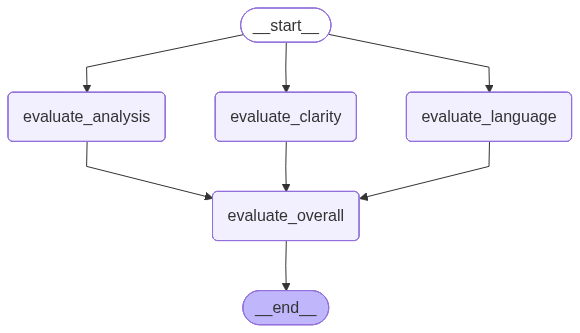

In [110]:
workflow

In [111]:
initial_state = {
    "essaytext": essay
}

workflow.invoke(initial_state)

{'essaytext': "\n\nThe Importance of Curiosity in Human Life\n\nCuriosity is one of the most powerful traits that human beings possess. It is the desire to learn, explore, and understand the world around us. From childhood to adulthood, curiosity drives people to ask questions, seek answers, and discover new possibilities. Without curiosity, many of the advancements in science, technology, and society would never have been achieved.\n\nOne of the greatest benefits of curiosity is that it promotes learning. Curious individuals are naturally motivated to acquire knowledge and develop new skills. They do not simply accept information at face value; instead, they investigate, analyze, and think critically. This habit of continuous learning helps people adapt to changing circumstances and become more informed citizens.\n\nCuriosity also plays a vital role in innovation. Throughout history, inventors, scientists, and explorers have made groundbreaking discoveries because they were curious ab

In [112]:
essay2 = """
My Favorite Food

My favorite food is pizza because pizza is my favorite food. I like pizza a lot and it tastes good. Pizza is made of pizza things like cheese and bread and other toppings. Many people eat pizza because pizza is popular.

Pizza is good because when I am hungry I eat pizza. Sometimes I eat pizza on weekends. Sometimes I don't. There are many types of pizza and they are different from each other. Some pizzas have cheese and some have more cheese. This is one reason why pizza is interesting.

Another thing about pizza is that it comes in a circle. The circle can be cut into triangles. Geometry is important because pizza has shapes. This shows that pizza is educational in some ways.

In conclusion, pizza is my favorite food because I like it. It tastes nice and many people eat it. Pizza is a food that exists and that is why it is my favorite food."""

In [116]:
initial_state = {
    "essaytext": essay2,
}
workflow.invoke(initial_state)

OutputParserException: Failed to parse EvaluationState from completion {"feedback": "The essay lacks depth and originality in its arguments. The student relies heavily on repetitive statements and fails to provide concrete evidence to support their claims. The writing is simple and lacks variety in sentence structure. However, the student shows some understanding of basic geometry concepts. To improve"}. Got: 1 validation error for EvaluationState
score
  Field required [type=missing, input_value={'feedback': 'The essay l...y concepts. To improve'}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 